<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [3]:
#print columns missing values
for col in df.columns:
    missing = df[col].isna().sum()
    print(col , ':' , missing)

ResponseId : 0
MainBranch : 0
Age : 0
Employment : 0
RemoteWork : 10631
Check : 0
CodingActivities : 10971
EdLevel : 4653
LearnCode : 4949
LearnCodeOnline : 16200
TechDoc : 24540
YearsCode : 5568
YearsCodePro : 13827
DevType : 5992
OrgSize : 17957
PurchaseInfluence : 18031
BuyNewTool : 20256
BuildvsBuy : 22079
TechEndorse : 21769
Country : 6507
Currency : 18753
CompTotal : 31697
LanguageHaveWorkedWith : 5692
LanguageWantToWorkWith : 9685
LanguageAdmired : 14565
DatabaseHaveWorkedWith : 15183
DatabaseWantToWorkWith : 22879
DatabaseAdmired : 26880
PlatformHaveWorkedWith : 23071
PlatformWantToWorkWith : 30905
PlatformAdmired : 34060
WebframeHaveWorkedWith : 20276
WebframeWantToWorkWith : 26902
WebframeAdmired : 30494
EmbeddedHaveWorkedWith : 43223
EmbeddedWantToWorkWith : 47837
EmbeddedAdmired : 48704
MiscTechHaveWorkedWith : 25994
MiscTechWantToWorkWith : 32473
MiscTechAdmired : 35841
ToolsTechHaveWorkedWith : 12955
ToolsTechWantToWorkWith : 19353
ToolsTechAdmired : 21440
NEWCollabToolsH

<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


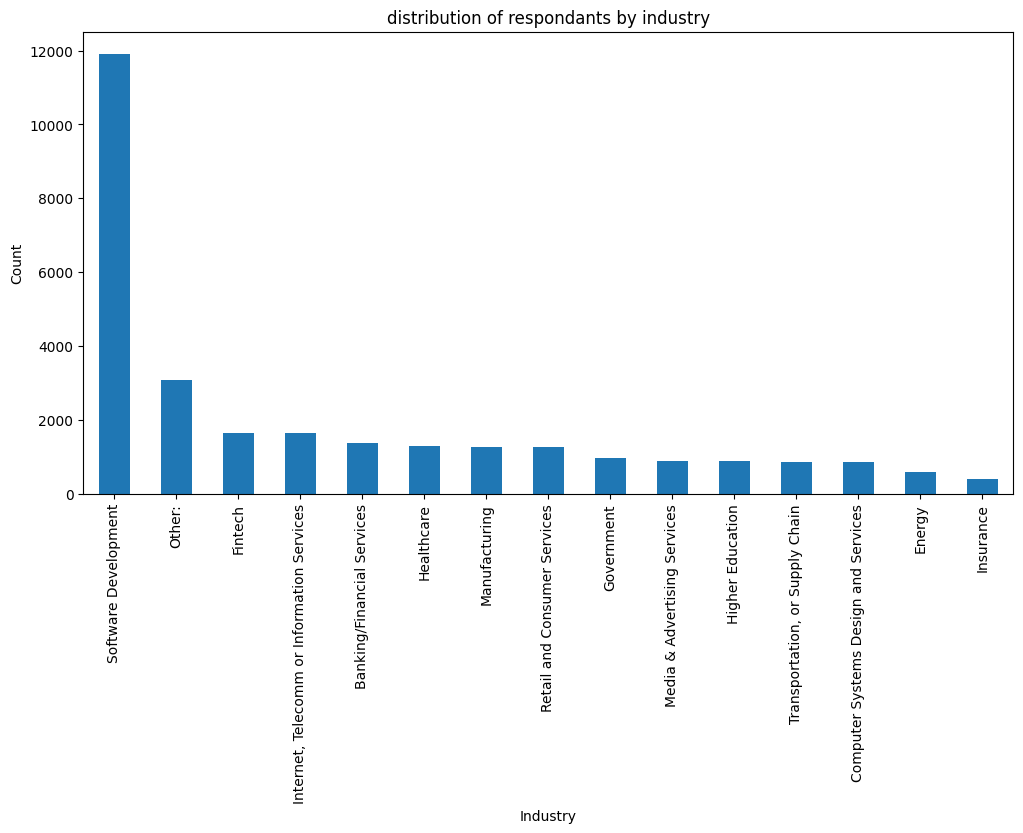

In [4]:
##Write your code here
df['Industry'].value_counts().plot(kind = 'bar' , figsize = (12 , 6))

plt.xlabel('Industry')
plt.ylabel('Count')
plt.title('distribution of respondants by industry')
plt.xticks(rotation=90)
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
##base stats
df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [6]:
#find outliers
mean_compy = df['ConvertedCompYearly'].mean()
std_compy = df['ConvertedCompYearly'].std()

std_outliers = df[df['ConvertedCompYearly'] > mean_compy + 3 * std_compy]
std_outliers['ConvertedCompYearly'].value_counts()

ConvertedCompYearly
750000.0      11
1000000.0      6
650000.0       4
700000.0       4
1200000.0      4
800000.0       3
1500000.0      3
2000000.0      2
1074062.0      2
1188001.0      2
859250.0       2
945000.0       1
1302817.0      1
1031099.0      1
1052581.0      1
1728025.0      1
950000.0       1
1184707.0      1
798000.0       1
1273879.0      1
1332930.0      1
13818022.0     1
660660.0       1
803285.0       1
2048046.0      1
670000.0       1
1750749.0      1
740517.0       1
16256603.0     1
1550391.0      1
6340564.0      1
4936778.0      1
875000.0       1
3367716.0      1
1562898.0      1
2014062.0      1
713372.0       1
2584118.0      1
764327.0       1
1250348.0      1
912953.0       1
810000.0       1
1295242.0      1
9000000.0      1
980887.0       1
850000.0       1
720000.0       1
675000.0       1
1750000.0      1
712801.0       1
2237846.0      1
2153432.0      1
1140481.0      1
1900000.0      1
1288874.0      1
900000.0       1
1300000.0      1
Name: count

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [7]:
##find IQR
q1_compy = df['ConvertedCompYearly'].describe()['25%']
q3_compy = df['ConvertedCompYearly'].describe()['75%']
iqr_compy = q3_compy - q1_compy
print('IQR:' , iqr_compy)

IQR: 75259.5


In [8]:
#find bounds
Lbound_compy = q1_compy - 1.5 * iqr_compy
Ubound_compy = q3_compy + 1.5 * iqr_compy
print('lower bound:' , Lbound_compy)
print('upper bound:' , Ubound_compy)

lower bound: -80177.25
upper bound: 220860.75


In [11]:
#find iqr outliers
iqr_outliers = df[(df['ConvertedCompYearly'] < Lbound_compy) | (df['ConvertedCompYearly'] > Ubound_compy)]
iqr_outliers['ConvertedCompYearly'].value_counts()

ConvertedCompYearly
250000.0     103
300000.0      64
230000.0      44
240000.0      43
225000.0      40
            ... 
1300000.0      1
332712.0       1
511974.0       1
429429.0       1
438767.0       1
Name: count, Length: 294, dtype: int64

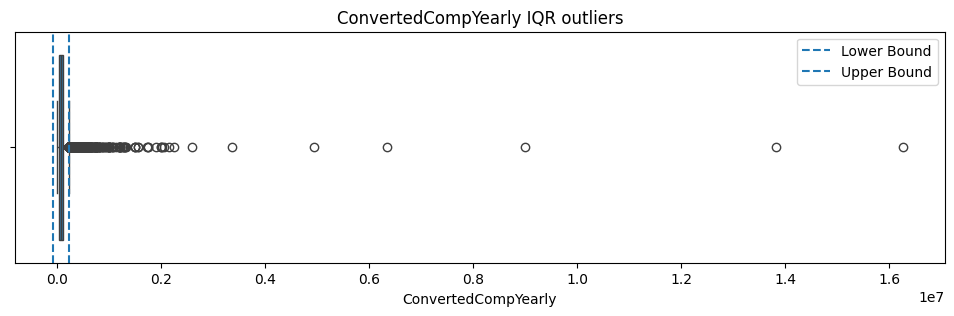

In [13]:
#visualize outliers in a box plot
plt.figure(figsize = (12 , 3))
sns.boxplot(x = df['ConvertedCompYearly'])
plt.axvline(Lbound_compy , linestyle = '--' , label = 'Lower Bound')
plt.axvline(Ubound_compy , linestyle = '--' , label = 'Upper Bound')
plt.title('ConvertedCompYearly IQR outliers')
plt.xlabel('ConvertedCompYearly')
plt.legend()

plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [15]:
##Write your code here
noiqr_compy = df[(df['ConvertedCompYearly'] >= Lbound_compy) & (df['ConvertedCompYearly'] <= Ubound_compy)]
noiqr_compy.size

2560098

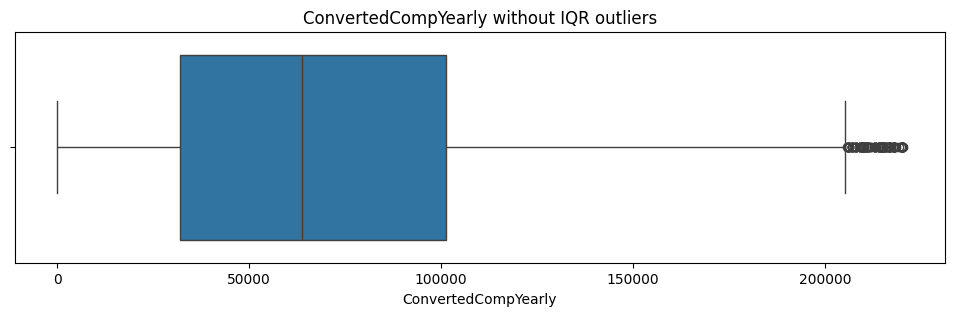

In [17]:
plt.figure(figsize = (12 , 3))
sns.boxplot(x = noiqr_compy['ConvertedCompYearly'])
plt.title('ConvertedCompYearly without IQR outliers')
plt.xlabel('ConvertedCompYearly')

plt.show()

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [22]:
##check out column values
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [23]:
#map age column to random numbers within its value eg. 25-34 gets a random number between 25 and 34.
import numpy as np
age_ranges = {
    'Under 18 years old': (0, 17),
    '18-24 years old': (18, 24),
    '25-34 years old': (25, 34),
    '35-44 years old': (35, 44),
    '45-54 years old': (45, 54),
    '55-64 years old': (55, 64),
    '65 years or older': (65, 90),
    'Prefer not to say': (0 , 90)
}

def random_age(age_grp):
    if age_grp in age_ranges:
        low , high = age_ranges[age_grp]
        return np.random.randint(low , high + 1)
    return np.nan

df['AgeNumber'] = df['Age'].apply(random_age)

df['AgeNumber'].value_counts()

AgeNumber
32    2493
31    2451
26    2411
25    2409
27    2403
      ... 
82      28
86      28
65      28
88      27
67      26
Name: count, Length: 91, dtype: int64

In [29]:
#calculate correlations - 
noiqr_compy['AgeNumber'] = noiqr_compy['Age'].apply(random_age)
corr_agejobsatsalary = noiqr_compy[['AgeNumber', 'JobSat', 'ConvertedCompYearly']].corr()
corr_agejobsatsalary

,AgeNumber,JobSat,ConvertedCompYearly
AgeNumber,1.000000,0.063848,0.354103
JobSat,0.063848,1.000000,0.075244
ConvertedCompYearly,0.354103,0.075244,1.000000


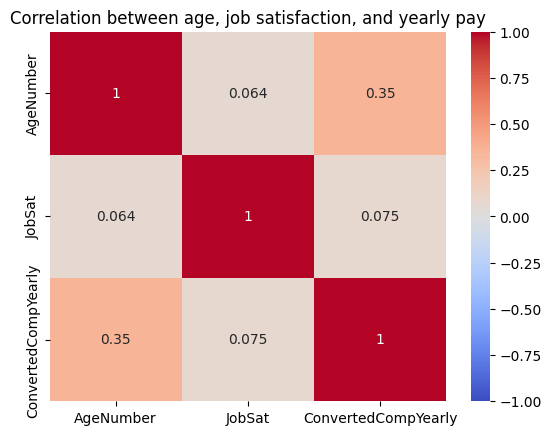

In [30]:
#visualize matrix
sns.heatmap(corr_agejobsatsalary , annot = True , cmap = 'coolwarm' , vmin = -1 , vmax = 1)

plt.title('Correlation between age, job satisfaction, and yearly pay')
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
